# SCSAP — Tutorial notebook

End-to-end walk through the spatial-cell analysis pipeline used in the paper.
Heavy feature-extraction steps (per-image `psi_k` and local-density sweeps
across all cell-type combinations and bond radii) are GPU-expensive and
pre-computed — the CSVs under
`data/features/<dataset>/data_filtered_<radius>.csv` are the outputs of that
run. The downstream statistical analyses (KS testing, random-forest
classification, HSIC independence test) are reproduced here directly from
those CSVs, using the helpers in `src/*.py`.

## Pipeline at a glance

1. **Load raw cells** — per-image dataframes for both datasets (CRC, CP_PDAC).
2. **Bond graphs** *(stub)* — neighbourhoods at a few radii for one image per
   pathology.
3. **Per-image feature maps** — local density and `|psi_6|` coloured by cell
   position on four example images.
4. **Read pre-computed features** — per-image aggregated CSVs at the chosen
   radius.
5. **KS test** — paper-figure replication: two-sample KS between pathology
   groups, plotted as filled KDEs.
6. **Random-forest classification** — 5-fold CV across feature subsets
   (all / density / psi / top-20) with bootstrap confidence intervals.
7. **HSIC** — independence test between the psi and density feature blocks
   swept over every available radius.

> Datasets used throughout:
> **CRC** (140 images, CLR vs DII pathology) and
> **CP_PDAC** (199 images, CP vs PDAC pathology).


## 1 · Load the raw cell-level data

Each row of the raw CSV is one cell with `(x, y)` coordinates, a cell-type
label, a pathology label, and image / patient identifiers. `load_dataset`
groups by `image_id`, deduplicates overlapping positions, builds a stable
string→int cell-type encoding, and returns `{image_id: dataframe}` together
with the shared encoding.


In [1]:
# Load the unified per-cell CSVs for both datasets. `load_dataset`
# returns a `{image_id: DataFrame}` dict plus the cell-type encoding,
# so a single function call handles all 140 + 199 images.
import sys
from pathlib import Path

# Notebook lives in `src/`; add the project root so `import src.*` works.
sys.path.insert(0, str(Path.cwd().parent))

from src.preprocessing import load_dataset

RAW = Path.cwd().parent / "data" / "raw"
DATASET_PATHS = {
    "CRC":     RAW / "CRC_unified.csv",
    "CP_PDAC": RAW / "CP_PDAC_unified.csv",
}

datasets = {}  # name -> (images dict, encoding)
for name, path in DATASET_PATHS.items():
    images, encoding = load_dataset(path)
    datasets[name] = (images, encoding)

    total_cells = sum(len(df) for df in images.values())
    pathologies = sorted({df["pathology"].iloc[0] for df in images.values()})
    print(f"=== {name} ===")
    print(f"  images:       {len(images)}")
    print(f"  cells:        {total_cells:,}")
    print(f"  cell types:   {len(encoding)}  ->  {list(encoding)}")
    print(f"  pathologies:  {pathologies}")
    print()


=== CRC ===
  images:       140
  cells:        258,385
  cell types:   17  ->  ['B cells', 'CD163+ macros', 'CD4+ T cells', 'CD68+ macros', 'CD8+ T cells', 'NK cells', 'Tregs', 'adipocytes', 'generic immune', 'granulocytes', 'memory CD4+ T', 'plasma cells', 'smooth muscle', 'stroma', 'tumor cells', 'undefined', 'vasculature']
  pathologies:  ['CLR', 'DII']



=== CP_PDAC ===
  images:       199
  cells:        267,544
  cell types:   5  ->  ['APC', 'CTL', 'Epi', 'THelper', 'Treg']
  pathologies:  ['CP', 'PDAC']



## 2 · Bond graphs at selected radii  *(stub)*

For one image per pathology, draw the freud neighbour graph at a few bond
radii to give an intuition for what "neighbour" means before any feature
extraction begins.

*Not implemented in this tutorial* — the underlying `_radius_nlist` helper
in `src/features.py` is what would be plotted.


In [2]:
# Stub: bond graphs at selected radii for one image per disease type.
# Use `src.features._radius_nlist(box, points, cutoff)` to obtain a freud
# NeighborList, then draw a line segment for each (query_point, point) pair.


## 3 · Per-image feature maps

For one image per `(dataset, pathology)` combination, compute two features
at the default bond cutoff (`bond_cutoff = 60.0`) and colour each cell's
spatial position by them:

* `local_density` — local cell density in a disk of radius `bond_cutoff`.
* `|psi_6|` — modulus of the hexatic bond-orientational order parameter
  (k = 6).

Four images × two features → an 8-panel grid. These are the kinds of maps
used to motivate the bulk feature sweeps in the paper.


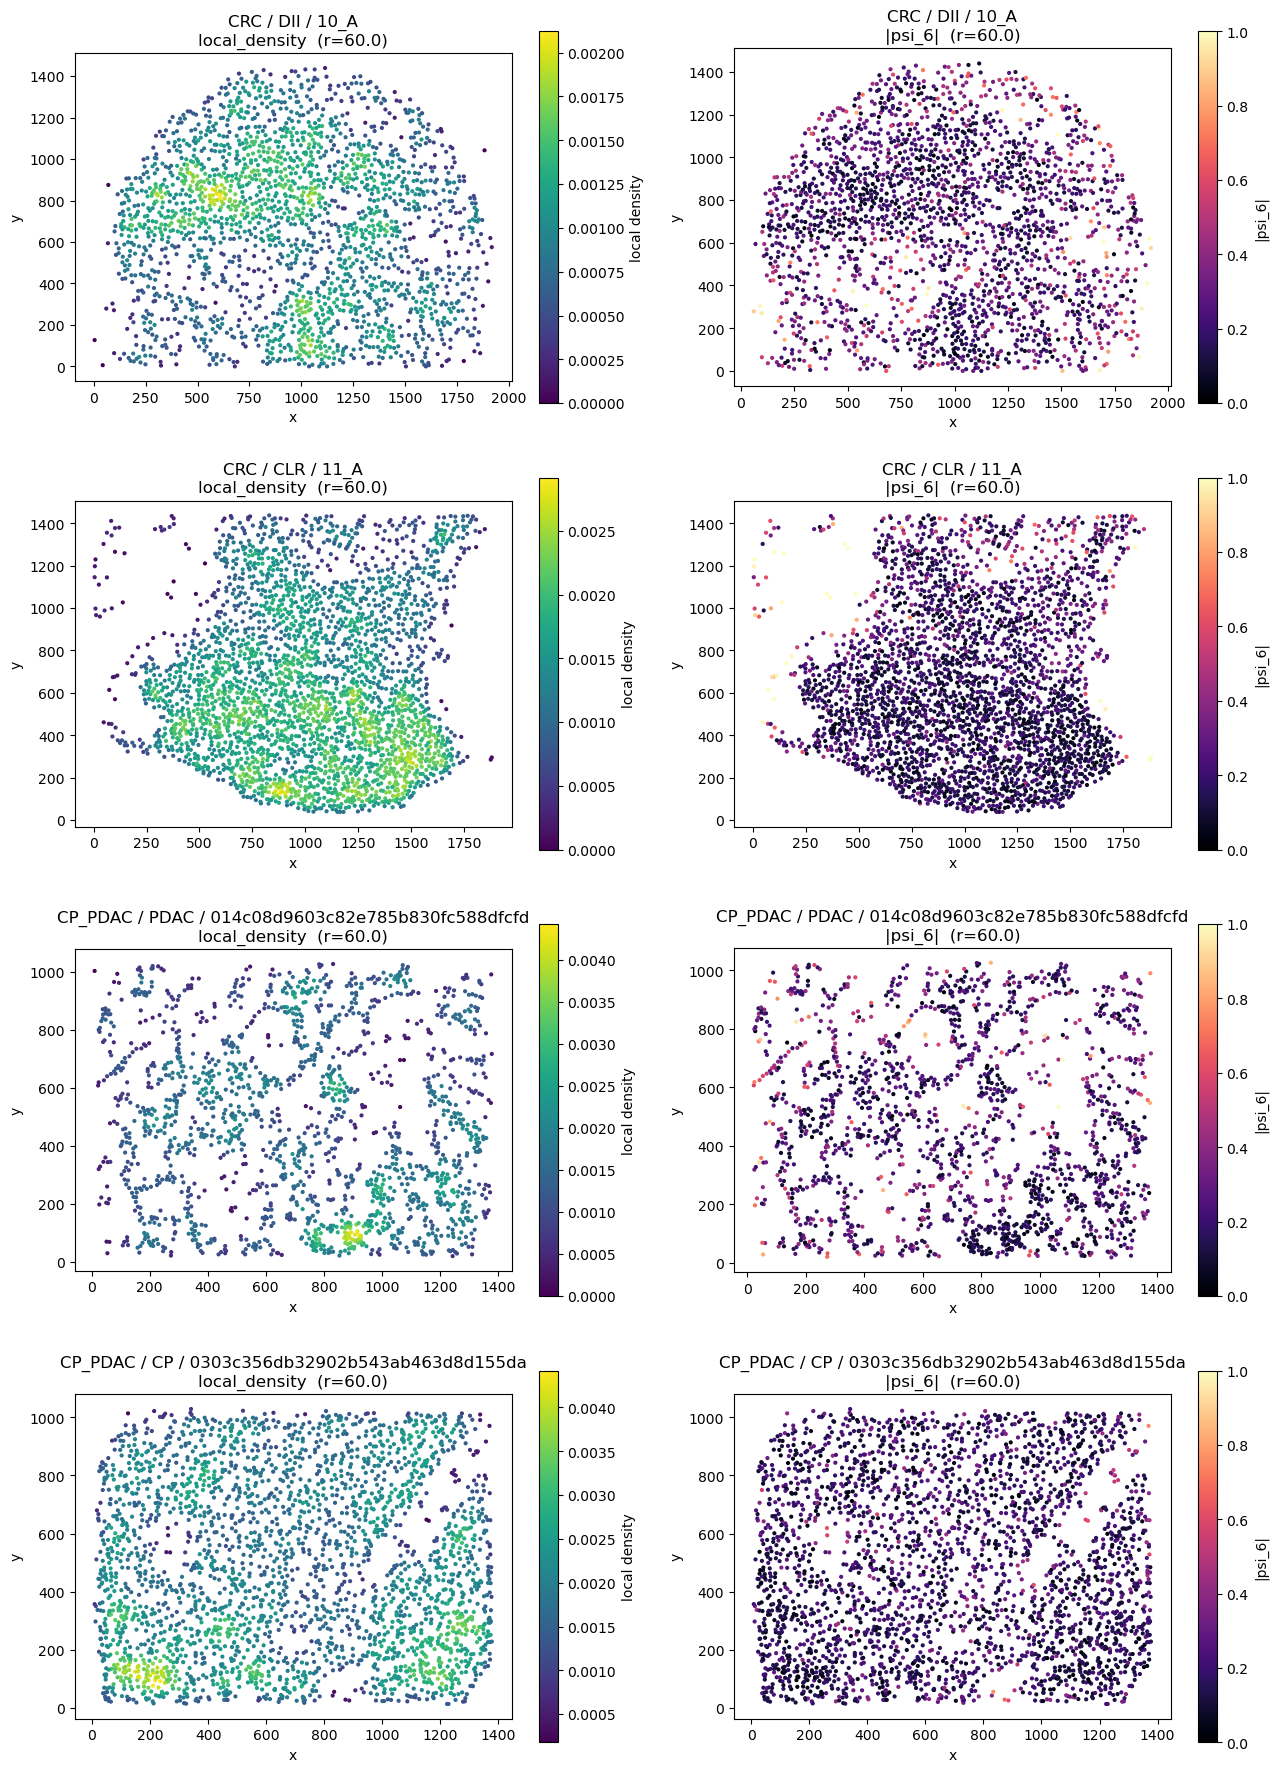

In [3]:
# Per-image feature maps for one image per (dataset, pathology) combination.
# We pick the first image we see in each pathology, compute local density and
# |psi_6| at the default bond cutoff, then scatter-plot the cells coloured by
# each feature.  4 images x 2 features = 8 panels.
import matplotlib.pyplot as plt

from src.features import compute_local_density, compute_katic_order

BOND_CUTOFF = 60.0   # configs/default.yaml
K = 6                # hexatic order parameter

# Pick one image per pathology from each dataset.
selections = []  # list of (dataset_name, pathology, image_id, df)
for name, (images, _) in datasets.items():
    seen = set()
    for image_id, df in images.items():
        pathology = df["pathology"].iloc[0]
        if pathology in seen:
            continue
        seen.add(pathology)
        selections.append((name, pathology, image_id, df))

fig, axes = plt.subplots(len(selections), 2, figsize=(13, 4.5 * len(selections)))

for row, (name, pathology, image_id, df) in enumerate(selections):
    cell_types = sorted(df["cell_type"].unique().tolist())

    # Adds a `local_density` column (one value per cell).
    df_feat = compute_local_density(df, cell_types=cell_types, cutoff=BOND_CUTOFF,
                                    include_neighbor_counts=False)
    # Adds `psi_{K}_all`, `psi_{K}_ngek`, `psi_{K}_nek` columns.
    df_feat = compute_katic_order(df_feat, cutoff=BOND_CUTOFF, k_values=[K])

    ax_ld = axes[row, 0]
    sc = ax_ld.scatter(df_feat["x"], df_feat["y"], c=df_feat["local_density"],
                       s=4, cmap="viridis")
    plt.colorbar(sc, ax=ax_ld, label="local density")
    ax_ld.set_title(f"{name} / {pathology} / {image_id}\nlocal_density  (r={BOND_CUTOFF})")
    ax_ld.set_aspect("equal")
    ax_ld.set_xlabel("x"); ax_ld.set_ylabel("y")

    ax_psi = axes[row, 1]
    sc = ax_psi.scatter(df_feat["x"], df_feat["y"], c=df_feat[f"psi_{K}_all"],
                        s=4, cmap="magma", vmin=0.0, vmax=1.0)
    plt.colorbar(sc, ax=ax_psi, label=f"|psi_{K}|")
    ax_psi.set_title(f"{name} / {pathology} / {image_id}\n|psi_{K}|  (r={BOND_CUTOFF})")
    ax_psi.set_aspect("equal")
    ax_psi.set_xlabel("x"); ax_psi.set_ylabel("y")

plt.tight_layout()
plt.show()


## 4 · Read pre-computed per-image features

Computing the full feature table from scratch is GPU-expensive — the per-image
CSVs at `data/features/<dataset>/data_filtered_<radius>.csv` are the cached
output of that pipeline. We pick one radius (`r = 240`, matching the radius
used in the paper figure replicated below) and load both datasets.

Available radii on disk: **30, 60, 90, 120, 180, 240**.


In [4]:
# Load the pre-computed per-image features for both datasets at one radius.
# Each row is one image; each column is one (cell-type-combo, feature)
# aggregated to a scalar (mean across cells in the image).
import pandas as pd

RADIUS = 240
FEATURES_DIR = Path.cwd().parent / "data" / "features"

FEATURE_PATHS = {
    "CRC":     FEATURES_DIR / "CRC"     / f"data_filtered_{RADIUS}.csv",
    "CP_PDAC": FEATURES_DIR / "CP_PDAC" / f"data_filtered_{RADIUS}.csv",
}

# Non-feature columns to exclude from any downstream feature lists.
META_COLS = ["job_id", "image_id", "pathology", "label", "dataset"]

feature_dfs = {}     # dataset name -> per-image feature dataframe
feature_cols = {}    # dataset name -> list of feature column names
for name, path in FEATURE_PATHS.items():
    df = pd.read_csv(path)
    feats = [c for c in df.columns if c not in META_COLS]
    feature_dfs[name] = df
    feature_cols[name] = feats

    print(f"=== {name}  (r={RADIUS}) ===")
    print(f"  images:    {len(df)}")
    print(f"  features:  {len(feats):,}")
    print(f"  by pathology: {df['pathology'].value_counts().to_dict()}")
    print()


=== CRC  (r=240) ===
  images:    140
  features:  16,893
  by pathology: {'DII': 72, 'CLR': 68}

=== CP_PDAC  (r=240) ===
  images:    199
  features:  1,714
  by pathology: {'PDAC': 143, 'CP': 56}



## 5 · KS test — paper figure replication

Two-sample Kolmogorov–Smirnov test comparing the two pathology groups on the
four features highlighted in the paper:

* **CP_PDAC** — local density of `Epi` cells, and `psi_8` on `Epi`.
* **CRC** — local density of `CD163+ macros` near `granulocytes`, and
  `psi_5` on the same pair.

`ks_test_per_feature` runs the test, `adjust_pvalues` appends
Benjamini–Hochberg (BH) and Benjamini–Yekutieli (BY) FDR-corrected p-values,
and `plot_ks_kde_grid` renders the filled-KDE comparison in the same style
as the paper figure.


=== CP_PDAC  (r=240) ===
                  feature  statistic      p_value   p_value_bh   p_value_by
local_density_Epi_240_Epi   0.743161 2.743017e-22 5.486034e-22 8.229051e-22
        psi_8_Epi_all_Epi   0.632345 1.113745e-15 1.113745e-15 1.670618e-15



=== CRC  (r=240) ===
                                                  feature  statistic      p_value   p_value_bh   p_value_by
local_density_CD163+ macros_granulocytes_240_granulocytes   0.465686 2.112836e-07 2.112836e-07 3.169254e-07
        psi_5_CD163+ macros_granulocytes_all_granulocytes   0.508987 8.394989e-09 1.678998e-08 2.518497e-08



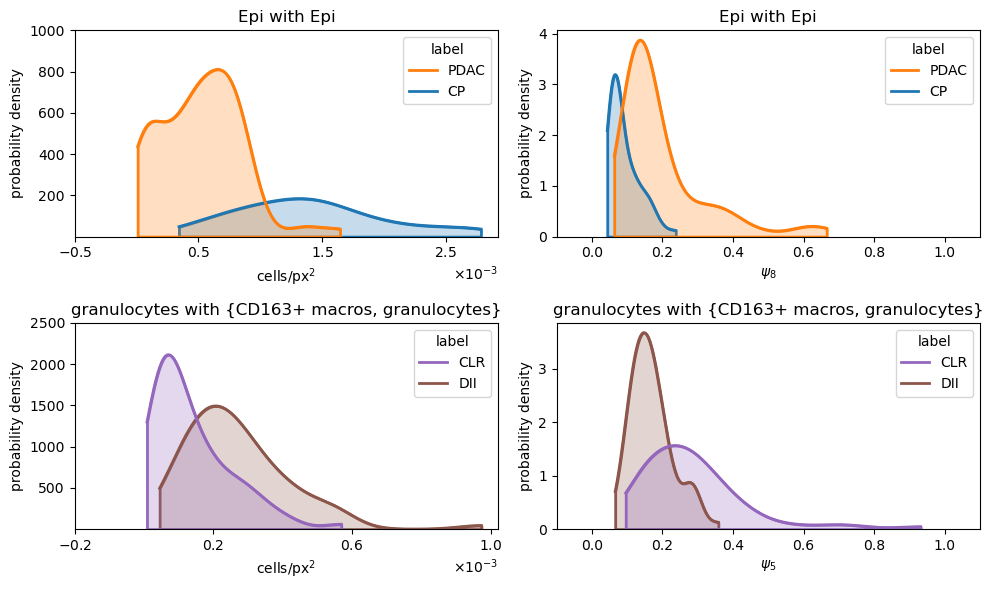

In [5]:
# KS test between the two pathology groups on the four features the paper
# figure highlights. `ks_test_per_feature` runs scipy's two-sample KS test
# per column; `adjust_pvalues` adds BH and BY FDR-corrected columns.
# `plot_ks_kde_grid` is a thin wrapper around seaborn.kdeplot that styles
# panels to match the paper figure (filled + outlined KDE, count-annotated
# legend, scientific-notation tick labels for densities, psi_k subscripts).
from src.stats import ks_test_per_feature, adjust_pvalues, plot_ks_kde_grid

PAPER_FEATURES = {
    "CP_PDAC": ["local_density_Epi_240_Epi",
                "psi_8_Epi_all_Epi"],
    "CRC":     ["local_density_CD163+ macros_granulocytes_240_granulocytes",
                "psi_5_CD163+ macros_granulocytes_all_granulocytes"],
}
# (colors, hue_order). The order matches seaborn's first-seen ordering in the
# CSVs (PDAC first in CP_PDAC, CLR first in CRC) so the colour mapping matches
# the published figure.
PALETTES = {
    "CP_PDAC": (["tab:orange", "tab:blue"],  ["PDAC", "CP"]),
    "CRC":     (["tab:purple", "tab:brown"], ["CLR", "DII"]),
}

for name, feats in PAPER_FEATURES.items():
    res = ks_test_per_feature(feature_dfs[name], feature_columns=feats,
                              group_column="pathology")
    res = adjust_pvalues(res, pvalue_column="p_value", methods=("bh", "by"))
    print(f"=== {name}  (r={RADIUS}) ===")
    print(res.to_string(index=False))
    print()

fig, _ = plot_ks_kde_grid(feature_dfs, PAPER_FEATURES, PALETTES, cutoff=RADIUS)
plt.show()


## 6 · Random-forest classification

Per-image features → pathology label. For each dataset we fit four
5-fold cross-validated random forests on different feature subsets:

| group        | features used                                              |
|--------------|------------------------------------------------------------|
| `all`        | every feature                                              |
| `density`    | local-density features only                                |
| `psi`        | order-parameter (`psi_k`) features only                    |
| `top20_all`  | top-20 features by impurity importance from the `all` model |

Out-of-fold AUROC / accuracy / balanced accuracy / F1 are reported, each
with a 1000-resample percentile bootstrap 95% CI. We also print the top-10
features by mean impurity importance from the `all` model — interpretable
pointers to which neighbourhoods are driving the classifier.


In [6]:
# Random-forest classification on the per-image features.
# For each dataset we fit four models — all / density / psi / top-20 — and
# report 5-fold out-of-fold metrics with 1000-rep bootstrap 95% CIs.
#
# Workflow:
#   1. `cross_validate_feature_groups` runs CV on {all, density, psi}.
#   2. The top-20 features (by impurity importance from the `all` model)
#      are then fed back through `cross_validate_random_forest_with_ci`
#      so the `top20_all` row uses the same CV + bootstrap machinery.
from src.ml import (
    select_psi_columns, select_density_columns,
    cross_validate_feature_groups, cross_validate_random_forest_with_ci,
    build_feature_matrix,
)

N_TOP = 20

ml_summaries = []
ml_importances = {}  # dataset -> {group: importances_df}

for name, df in feature_dfs.items():
    feats = feature_cols[name]
    groups = {
        "all":     feats,
        "density": select_density_columns(feats),
        "psi":     select_psi_columns(feats),
    }
    summary, importances = cross_validate_feature_groups(
        df, label_column="pathology", groups=groups,
    )

    # Top-20 features from the "all" model's mean impurity importance.
    top20 = importances["all"].head(N_TOP)["feature"].tolist()
    X_top, y_top = build_feature_matrix(df, label_column="pathology",
                                        feature_columns=top20)
    top_out = cross_validate_random_forest_with_ci(X_top, y_top)
    summary = pd.concat([
        summary,
        pd.DataFrame([{"group": "top20_all", "n_features": X_top.shape[1],
                       **top_out["summary"]}]),
    ], ignore_index=True)
    importances["top20_all"] = top_out["cv"]["feature_importances_table"]

    summary.insert(0, "dataset", name)
    ml_summaries.append(summary)
    ml_importances[name] = importances

ml_summary = pd.concat(ml_summaries, ignore_index=True)

print(f"=== RF cross-validation summary  (r={RADIUS}) ===")
with pd.option_context("display.float_format", lambda x: f"{x:.3f}",
                       "display.width", 200):
    print(ml_summary.to_string(index=False))

# Top-10 features driving the all-feature model for each dataset.
for name, groups in ml_importances.items():
    print(f"\n--- {name}: top-10 features (impurity importance, all-model) ---")
    print(groups["all"].head(10).to_string(index=False,
                                           float_format=lambda x: f"{x:.4f}"))


=== RF cross-validation summary  (r=240) ===
dataset     group  n_features  auroc  accuracy  balanced_accuracy    f1  accuracy_ci_lower  accuracy_ci_upper  balanced_accuracy_ci_lower  balanced_accuracy_ci_upper  f1_ci_lower  f1_ci_upper  auroc_ci_lower  auroc_ci_upper
    CRC       all       16893  0.813     0.750              0.749 0.762              0.679              0.814                       0.679                       0.814        0.681        0.829           0.736           0.879
    CRC   density        2178  0.834     0.771              0.770 0.784              0.693              0.836                       0.693                       0.836        0.699        0.850           0.759           0.897
    CRC       psi       14715  0.806     0.750              0.750 0.759              0.679              0.821                       0.679                       0.819        0.676        0.829           0.728           0.875
    CRC top20_all          20  0.826     0.771             

## 7 · HSIC — are the psi and density blocks independent?

The order-parameter (`psi`) and local-density blocks measure different
aspects of the same neighbourhood; if they were redundant we would expect
strong statistical dependence. The Hilbert–Schmidt Independence Criterion
measures that dependence using RBF kernels, and a permutation test gives a
null distribution.

We sweep every available radius (`30, 60, 90, 120, 180, 240`) for each
dataset and for each pathology split, summarise as the **null-Z** (observed
HSIC in standard deviations above the permutation null), and draw one
heatmap per dataset.

> Higher Z = stronger evidence that the two blocks carry related
> information. A monotonic increase with radius is expected: larger
> neighbourhoods aggregate more cells, so both blocks pick up more shared
> coarse-grained structure.


=== HSIC sweep across cutoffs and pathology splits ===
dataset    split  cutoff   n  n_psi  n_dens    hsic  p_value  z_score
    CRC combined      30 140  11522    2114 0.00168 0.000999     13.7
    CRC      CLR      30  68  10634    2066  0.0028 0.000999     6.26
    CRC      DII      30  72  10388    2114 0.00305 0.000999     8.01
    CRC combined      60 140  14243    2114 0.00192 0.000999     29.7
    CRC      CLR      60  68  13808    2098 0.00313 0.000999     12.6
    CRC      DII      60  72  13880    2114 0.00321 0.000999     14.4
    CRC combined      90 140  14608    2114 0.00212 0.000999     41.7
    CRC      CLR      90  68  14288    2114 0.00331 0.000999     21.4
    CRC      DII      90  72  14465    2114 0.00343 0.000999     18.5
    CRC combined     120 140  14691    2114 0.00226 0.000999     47.9
    CRC      CLR     120  68  14521    2114 0.00351 0.000999     26.3
    CRC      DII     120  72  14638    2114 0.00352 0.000999     20.1
    CRC combined     180 140  14713

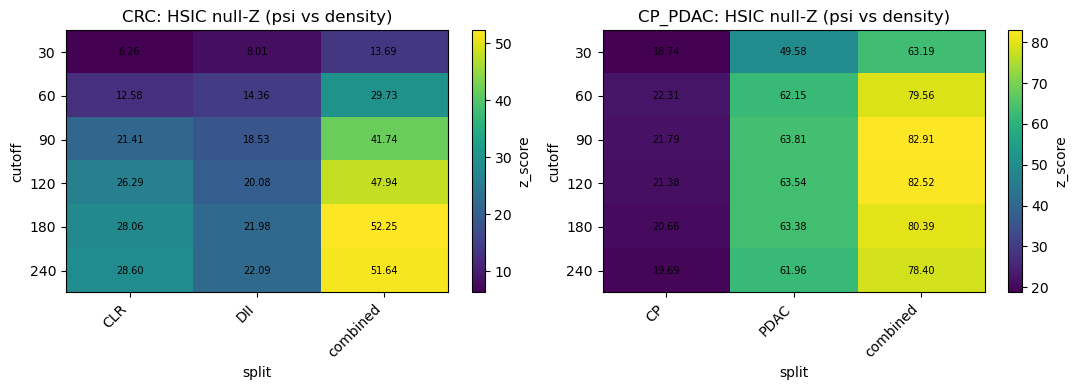

In [7]:
# HSIC permutation test for independence between the psi and local-density
# feature blocks, swept across every available bond radius. For each dataset
# we run the test on the combined sample and on each pathology split.
# The heatmap reports the null-Z (observed HSIC in standard deviations above
# the permutation null) — bigger = stronger dependence.
from src.hsic import hsic_test, prepare_psi_density_blocks, plot_hsic_heatmap

HSIC_CUTOFFS = [30, 60, 90, 120, 180, 240]
HSIC_PERMUTATIONS = 1000  # 5000 is the default; 1000 keeps the tutorial brisk.

hsic_rows = []
for name in ["CRC", "CP_PDAC"]:
    for cutoff in HSIC_CUTOFFS:
        df_c = pd.read_csv(FEATURES_DIR / name / f"data_filtered_{cutoff}.csv")

        splits = [("combined", df_c)]
        for path_label, sub in df_c.groupby("pathology"):
            splits.append((str(path_label), sub))

        for split_name, sub in splits:
            # prepare_psi_density_blocks picks psi/density columns, imputes
            # NaNs with column means, drops zero-variance columns, and z-scores.
            X, Y, psi_cols, dens_cols = prepare_psi_density_blocks(sub)
            if X.size == 0 or Y.size == 0 or X.shape[0] < 3:
                continue
            res = hsic_test(X, Y,
                            n_permutations=HSIC_PERMUTATIONS,
                            random_state=42)
            hsic_rows.append({
                "dataset": name, "split": split_name, "cutoff": cutoff,
                "n": int(sub.shape[0]),
                "n_psi": len(psi_cols), "n_dens": len(dens_cols),
                "hsic": res["hsic"], "p_value": res["p_value"],
                "z_score": res["z_score"],
            })

hsic_results = pd.DataFrame(hsic_rows)
print("=== HSIC sweep across cutoffs and pathology splits ===")
with pd.option_context("display.float_format", lambda x: f"{x:.3g}",
                       "display.width", 200):
    print(hsic_results.to_string(index=False))

# One heatmap per dataset: cutoff (rows) x split (columns), colour = null-Z.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name in zip(axes, ["CRC", "CP_PDAC"]):
    sub = hsic_results[hsic_results["dataset"] == name]
    plot_hsic_heatmap(sub, value="z_score", index="cutoff", columns="split",
                      cutoff_order=HSIC_CUTOFFS,
                      title=f"{name}: HSIC null-Z (psi vs density)",
                      ax=ax)
fig.tight_layout()
plt.show()
